In [1]:
# Cell 1: Install extra packages
!pip install -q scikit-learn
!pip install -q seaborn

print('All extra packages installed!')


All extra packages installed!


In [1]:
# Cell 2: Import all required libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use : {device}')
print(f'PyTorch version: {torch.__version__}')


Device in use : cuda
PyTorch version: 2.10.0+cu128


In [2]:
# Cell 3: Define transforms for training and validation

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomCrop(32, padding=4),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms defined successfully!')
print('  Training : resize + augmentation + normalize')
print('  Validation: resize + normalize only')


Transforms defined successfully!
  Training : resize + augmentation + normalize
  Validation: resize + normalize only


In [3]:
# Cell 4: Download CIFAR-10 and create mini (5,000-image) subset

print('Downloading CIFAR-10 dataset (first run only — ~170 MB)...')

full_train_raw = datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform
)
full_test_raw = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform
)

print(f'Full training set: {len(full_train_raw):,} images')
print(f'Full test set    : {len(full_test_raw):,} images')

import random
random.seed(42)

def make_balanced_subset(dataset, n_per_class=500, num_classes=10):
    targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset]
    indices_per_class = {c: [] for c in range(num_classes)}
    for idx, label in enumerate(targets):
        indices_per_class[label].append(idx)
    selected = []
    for c in range(num_classes):
        pool = indices_per_class[c]
        random.shuffle(pool)
        selected.extend(pool[:n_per_class])
    random.shuffle(selected)
    return Subset(dataset, selected)

mini_train_full = make_balanced_subset(full_train_raw, n_per_class=500)
mini_test       = make_balanced_subset(full_test_raw,  n_per_class=100)

print(f'Mini training set: {len(mini_train_full)} images')
print(f'Mini test set    : {len(mini_test)} images')

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f'Classes: {class_names}')


100%|██████████| 170M/170M [00:09<00:00, 17.9MB/s] 


Full training set: 50,000 images
Full test set    : 10,000 images
Mini training set: 5000 images
Mini test set    : 1000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Cell 5: Split mini training set into train (80%) / val (20%)

train_size = int(0.8 * len(mini_train_full))
val_size   = len(mini_train_full) - train_size

train_dataset, val_dataset = random_split(
    mini_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = mini_test

print('Dataset split summary:')
print(f'  Training   : {len(train_dataset):>5} images  (80%)')
print(f'  Validation : {len(val_dataset):>5} images  (20%)')
print(f'  Test       : {len(test_dataset):>5} images  (held-out)')


Dataset split summary:
  Training   :  4000 images  (80%)
  Validation :  1000 images  (20%)
  Test       :  1000 images  (held-out)


In [5]:
# Cell 6: Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'DataLoaders created  (batch size = {BATCH_SIZE})')
print(f'  Training batches  : {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')
print(f'  Test batches      : {len(test_loader)}')


DataLoaders created  (batch size = 32)
  Training batches  : 125
  Validation batches: 32
  Test batches      : 32


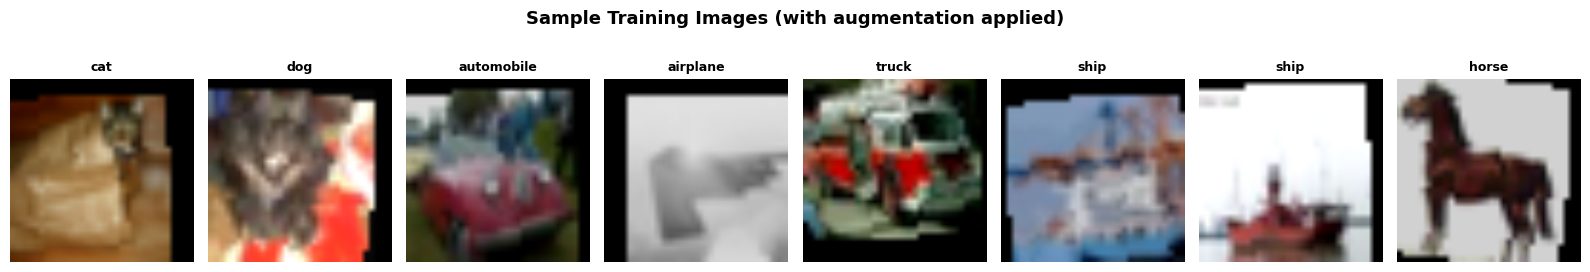

Notice: some images look slightly rotated or flipped — that is augmentation!


In [6]:
# Cell 7: Display 8 sample training images

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std) + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for i in range(8):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()], fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Training Images (with augmentation applied)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: some images look slightly rotated or flipped — that is augmentation!')


In [7]:
# Cell 8: Load pretrained ResNet18 and adapt for 10-class output

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print('Original final layer (fc):', model.fc)

# Step 1: Freeze ALL pretrained layers
for param in model.parameters():
    param.requires_grad = False

print('All pretrained layers frozen.')

# Step 2: Replace the final fully-connected layer
NUM_CLASSES = 10
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

print(f'New final layer (fc): {model.fc}')

# Step 3: Move model to device
model = model.to(device)

# Count parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f'Trainable parameters : {trainable:>10,}  ({100*trainable/total:.2f}%)')
print(f'Frozen parameters    : {total-trainable:>10,}  ({100*(total-trainable)/total:.2f}%)')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s] 


Original final layer (fc): Linear(in_features=512, out_features=1000, bias=True)
All pretrained layers frozen.
New final layer (fc): Linear(in_features=512, out_features=10, bias=True)
Trainable parameters :      5,130  (0.05%)
Frozen parameters    : 11,176,512  (99.95%)


In [9]:
# Cell 9: Configure the training components

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimiser — only the new final layer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print('Training components ready:')
print('  Loss function : CrossEntropyLoss')
print('  Optimiser     : Adam  (lr=0.001)')
print('  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)')


Training components ready:
  Loss function : CrossEntropyLoss
  Optimiser     : Adam  (lr=0.001)
  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)


In [10]:
# Cell 10: Define training and validation helper functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, dim=1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

        if batch_idx % 50 == 0:
            print(f'    Batch {batch_idx:3d}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(loader), 100.0 * correct / total

print('Training and evaluation functions defined!')


Training and evaluation functions defined!


In [11]:
# Cell 11: Main training loop

NUM_EPOCHS   = 10
best_val_acc = 0.0

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

print('=' * 60)
print('  STARTING TRAINING')
print(f'  Epochs: {NUM_EPOCHS}  |  Batches per epoch: {len(train_loader)}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)

    print(f'  Train ->  Loss: {train_loss:.4f}  |  Accuracy: {train_acc:.2f}%')
    print(f'  Val   ->  Loss: {val_loss:.4f}  |  Accuracy: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  NEW BEST MODEL saved!  Val Accuracy: {val_acc:.2f}%')

print('\n' + '=' * 60)
print('  TRAINING COMPLETE!')
print(f'  Best validation accuracy: {best_val_acc:.2f}%')
print('=' * 60)


  STARTING TRAINING
  Epochs: 10  |  Batches per epoch: 125

Epoch 1/10
----------------------------------------
    Batch   0/125 | Loss: 2.6438
    Batch  50/125 | Loss: 1.8187
    Batch 100/125 | Loss: 1.2717
  Train ->  Loss: 1.7560  |  Accuracy: 41.05%
  Val   ->  Loss: 1.3244  |  Accuracy: 59.60%
  NEW BEST MODEL saved!  Val Accuracy: 59.60%

Epoch 2/10
----------------------------------------
    Batch   0/125 | Loss: 1.5587
    Batch  50/125 | Loss: 1.0705
    Batch 100/125 | Loss: 1.2670
  Train ->  Loss: 1.2539  |  Accuracy: 59.50%
  Val   ->  Loss: 1.1058  |  Accuracy: 64.90%
  NEW BEST MODEL saved!  Val Accuracy: 64.90%

Epoch 3/10
----------------------------------------
    Batch   0/125 | Loss: 1.1377
    Batch  50/125 | Loss: 1.4914
    Batch 100/125 | Loss: 1.4272
  Train ->  Loss: 1.1022  |  Accuracy: 63.80%
  Val   ->  Loss: 1.0466  |  Accuracy: 65.00%
  NEW BEST MODEL saved!  Val Accuracy: 65.00%

Epoch 4/10
----------------------------------------
    Batch   0/125

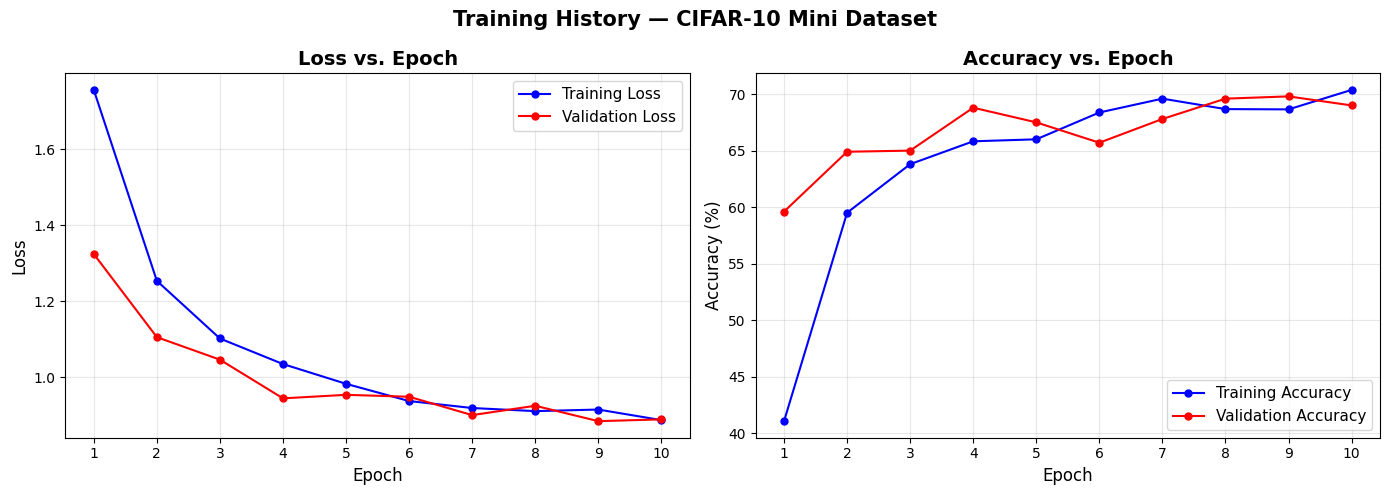

Good! Train-val gap is 1.4% -- model generalises well.


In [14]:
# Cell 12: Plot loss and accuracy curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss',   markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', markersize=5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss vs. Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(epochs_range))

ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy',   markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', markersize=5)
ax2.set_xlabel('Epoch',        fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy vs. Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(epochs_range))

plt.suptitle('Training History — CIFAR-10 Mini Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

final_gap = history['train_acc'][-1] - history['val_acc'][-1]
if final_gap > 15:
    print(f'WARNING: Large train-val gap ({final_gap:.1f}%) -- possible overfitting!')
elif final_gap < -5:
    print(f'NOTE: Validation > Training -- usually fine with strong augmentation.')
else:
    print(f'Good! Train-val gap is {final_gap:.1f}% -- model generalises well.')


In [15]:
# Cell 13: Evaluate on the held-out test set

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=3
))


Test Accuracy: 0.7530  (75.30%)

Classification Report:
              precision    recall  f1-score   support

    airplane      0.897     0.610     0.726       100
  automobile      0.744     0.900     0.814       100
        bird      0.739     0.650     0.691       100
         cat      0.624     0.530     0.573       100
        deer      0.787     0.630     0.700       100
         dog      0.654     0.850     0.739       100
        frog      0.748     0.890     0.813       100
       horse      0.798     0.790     0.794       100
        ship      0.746     0.910     0.820       100
       truck      0.875     0.770     0.819       100

    accuracy                          0.753      1000
   macro avg      0.761     0.753     0.749      1000
weighted avg      0.761     0.753     0.749      1000



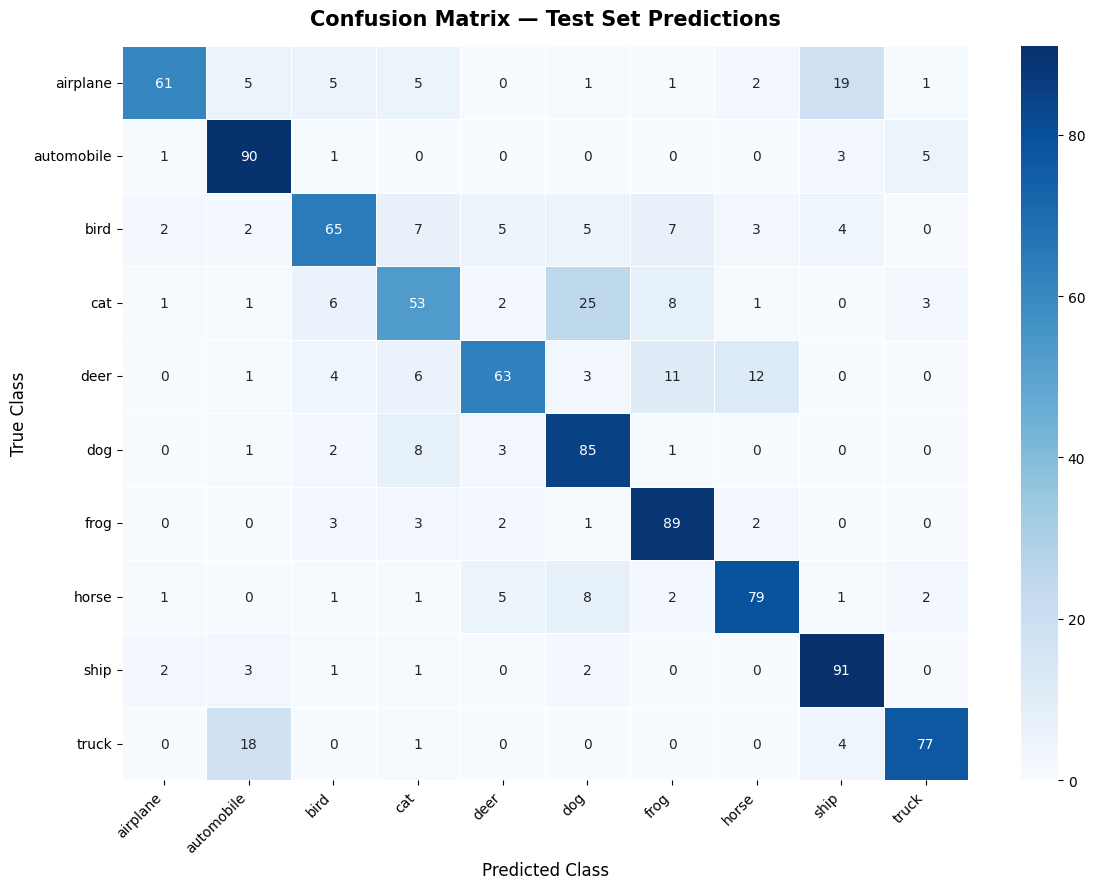

Most common mistake:
  True class  : cat
  Predicted as: dog
  Times        : 25

Per-class accuracy:
  airplane     ############         61.0%
  automobile   ##################   90.0%
  bird         #############        65.0%
  cat          ##########           53.0%
  deer         ############         63.0%
  dog          #################    85.0%
  frog         #################    89.0%
  horse        ###############      79.0%
  ship         ##################   91.0%
  truck        ###############      77.0%


In [16]:
# Cell 14: Confusion matrix visualisation

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Confusion Matrix — Test Set Predictions', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
worst = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
print(f'Most common mistake:')
print(f'  True class  : {class_names[worst[0]]}')
print(f'  Predicted as: {class_names[worst[1]]}')
print(f'  Times        : {cm_copy[worst]}')

per_class = cm.diagonal() / cm.sum(axis=1)
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    bar = '#' * int(per_class[i] * 20)
    print(f'  {name:12s} {bar:<20} {per_class[i]:.1%}')


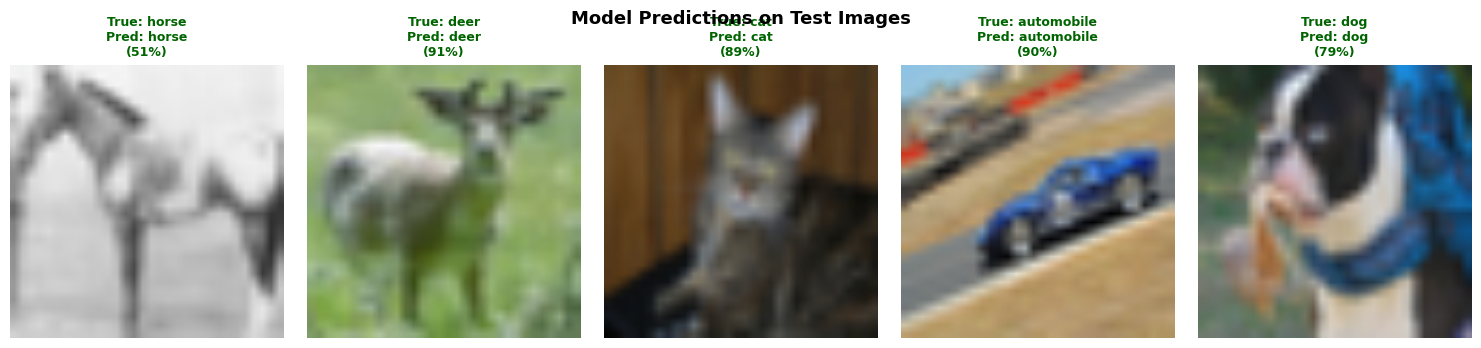

Green titles = correct  |  Red titles = incorrect


In [17]:
# Cell 15: Show predictions on 5 test images side by side

test_images, test_labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
model.eval()

for i in range(5):
    img_display = denormalize(test_images[i]).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    single_input = test_images[i].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(single_input)
        prob   = torch.nn.functional.softmax(output[0], dim=0)
        pred   = torch.argmax(prob).item()
        conf   = prob[pred].item()

    true_lbl = class_names[test_labels[i].item()]
    pred_lbl = class_names[pred]
    colour   = 'darkgreen' if pred == test_labels[i].item() else 'darkred'

    axes[i].imshow(img_display)
    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n({conf:.0%})',
        fontsize=9, fontweight='bold', color=colour
    )
    axes[i].axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Green titles = correct  |  Red titles = incorrect')


In [18]:
# Cell 16: predict_image() — works on any JPG/PNG file

def predict_image(image_path, model, class_names, device):
    image = Image.open(image_path).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])

    tensor = preprocess(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)

    probs = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, pred_idx = torch.max(probs, dim=0)
    predicted_class = class_names[pred_idx.item()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(image)
    ax1.set_title(
        f'Predicted: {predicted_class.upper()}\nConfidence: {confidence.item():.1%}',
        fontsize=13, fontweight='bold', color='navy'
    )
    ax1.axis('off')

    top5_probs, top5_idx = torch.topk(probs, 5)
    top5_names  = [class_names[i.item()] for i in top5_idx]
    top5_values = [p.item() * 100 for p in top5_probs]

    colours = ['#1565C0' if i == 0 else '#90CAF9' for i in range(5)]
    ax2.barh(top5_names[::-1], top5_values[::-1], color=colours[::-1])
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)

    for j, (val, name) in enumerate(zip(top5_values[::-1], top5_names[::-1])):
        ax2.text(val + 1, j, f'{val:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence.item()

print('predict_image() function defined and ready!')
print("Usage:  predict_image('path/to/photo.jpg', model, class_names, device)")


predict_image() function defined and ready!
Usage:  predict_image('path/to/photo.jpg', model, class_names, device)


Saved sample image.  True class: horse


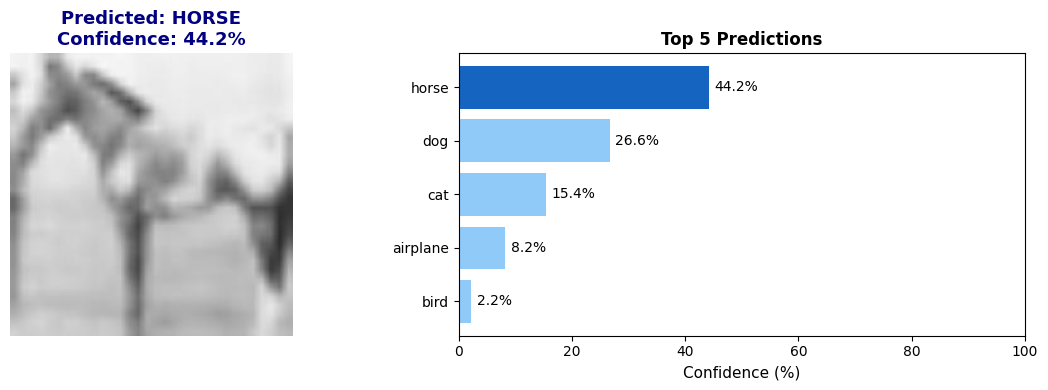

Predicted: horse  |  Confidence: 44.2%
CORRECT prediction!


In [19]:
# Cell 17: Test predict_image() using an image from the test set

sample_img_tensor, sample_label = test_dataset[0]

sample_pil = denormalize(sample_img_tensor).permute(1, 2, 0).numpy()
sample_pil = np.clip(sample_pil * 255, 0, 255).astype(np.uint8)
pil_img    = Image.fromarray(sample_pil)
pil_img.save('sample_test_image.jpg')

true_class = class_names[sample_label]
print(f'Saved sample image.  True class: {true_class}')

pred, conf = predict_image('sample_test_image.jpg', model, class_names, device)
print(f'Predicted: {pred}  |  Confidence: {conf:.1%}')

if pred == true_class:
    print('CORRECT prediction!')
else:
    print(f'WRONG — true class was {true_class}')


In [20]:
# Cell 18: Save a complete checkpoint and load it back

checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : class_names,
    'num_classes'         : NUM_CLASSES,
    'architecture'        : 'resnet18',
    'training_history'    : history
}
torch.save(checkpoint, 'cifar10_mini_checkpoint.pth')
print('Checkpoint saved to cifar10_mini_checkpoint.pth')

def load_checkpoint(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)

    loaded_model = models.resnet18(weights=None)
    loaded_model.fc = nn.Linear(
        loaded_model.fc.in_features,
        ckpt['num_classes']
    )
    loaded_model.load_state_dict(ckpt['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    print(f"Loaded model from {checkpoint_path}")
    print(f"Best validation accuracy: {ckpt['best_val_acc']:.2f}%")
    return loaded_model, ckpt['class_names']

reloaded_model, reloaded_classes = load_checkpoint('cifar10_mini_checkpoint.pth', device)
print(f'Classes: {reloaded_classes}')


Checkpoint saved to cifar10_mini_checkpoint.pth
Loaded model from cifar10_mini_checkpoint.pth
Best validation accuracy: 69.80%
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [21]:
# Saari important files ek jagah dekho
import os
files = ['best_model.pth', 'cifar10_mini_checkpoint.pth', 
         'training_curves.png', 'confusion_matrix.png', 
         'sample_test_image.jpg']

for f in files:
    exists = os.path.exists(f)
    print(f'{"✓" if exists else "✗"} {f}')

✓ best_model.pth
✓ cifar10_mini_checkpoint.pth
✓ training_curves.png
✓ confusion_matrix.png
✓ sample_test_image.jpg
